In [1]:
import sys
import os
import logging

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
logging.getLogger('tensorflow').setLevel(logging.FATAL)
try:
    from absl import logging as absl_logging
    absl_logging.set_verbosity(absl_logging.ERROR)
except ImportError:
    pass

import subprocess

REPO_URL = "https://github.com/mociatto/EcoFair.git"
REPO_DIR = "EcoFair"

if os.path.exists("./src"):
    sys.path.insert(0, os.path.abspath("."))
elif os.path.exists(os.path.join(".", REPO_DIR, "src")):
    sys.path.insert(0, os.path.abspath(REPO_DIR))
else:
    subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    sys.path.insert(0, os.path.abspath(REPO_DIR))

from src import config, utils, data_loader, models, training, features, routing, fairness, visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Cloning into 'EcoFair'...
E0000 00:00:1773394855.919356      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773394855.983594      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773394856.505511      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773394856.505570      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773394856.505574      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773394856.505576      23 computation_placer.cc:177] computation placer already regi

In [2]:
META_PATH = '/kaggle/input/datasets/mahdavi1202/skin-cancer/metadata.csv'
OUTPUT_BASE = '/kaggle/input/notebooks/mostafaanoosha' if os.path.exists('/kaggle') else './output'

CLASSES = ['bcc', 'scc', 'mel', 'ack', 'nev', 'sek']
SAFE_CLASSES = ['ack', 'nev', 'sek']
DANGEROUS_CLASSES = ['mel', 'bcc', 'scc']

TITLE_SUFFIX = ' — PAD-UFES-20'
DATASET_NAME = 'PAD-UFES-20'
OUTPUT_DIR = os.path.join('./output', 'pipeline_results', DATASET_NAME)

# Build pair directories from config.MODEL_PAIRS
PAIRS = [
    (os.path.join(OUTPUT_BASE, 'image-feature-extractor-lite', 'output', 'PAD-UFES-20', p['lite']),
     os.path.join(OUTPUT_BASE, 'image-feature-extractor-heavy', 'output', 'PAD-UFES-20', p['heavy']))
    for p in config.MODEL_PAIRS
]
PAIR_LABELS = [f"{p['lite']} → {p['heavy']}" for p in config.MODEL_PAIRS]

utils.set_seed(config.RANDOM_STATE)

In [3]:
pairs_data, meta = data_loader.load_dataset_features_multi(
    PAIRS, META_PATH,
)

In [4]:
loc_risk_scores = features.compute_localization_risk_scores(meta, dangerous_classes=DANGEROUS_CLASSES)
X_tab, scaler, sex_encoder, loc_encoder, risk_scaler = features.prepare_tabular_features(
    meta, localization_risk_scores=loc_risk_scores
)
y, _ = features.prepare_labels(meta, class_names=CLASSES)
meta = meta.copy()
meta['risk_score'] = features.calculate_cumulative_risk(
    meta, risk_scaler, localization_risk_scores=loc_risk_scores
)


Metadata distributions (age, localization, malignancy rate):



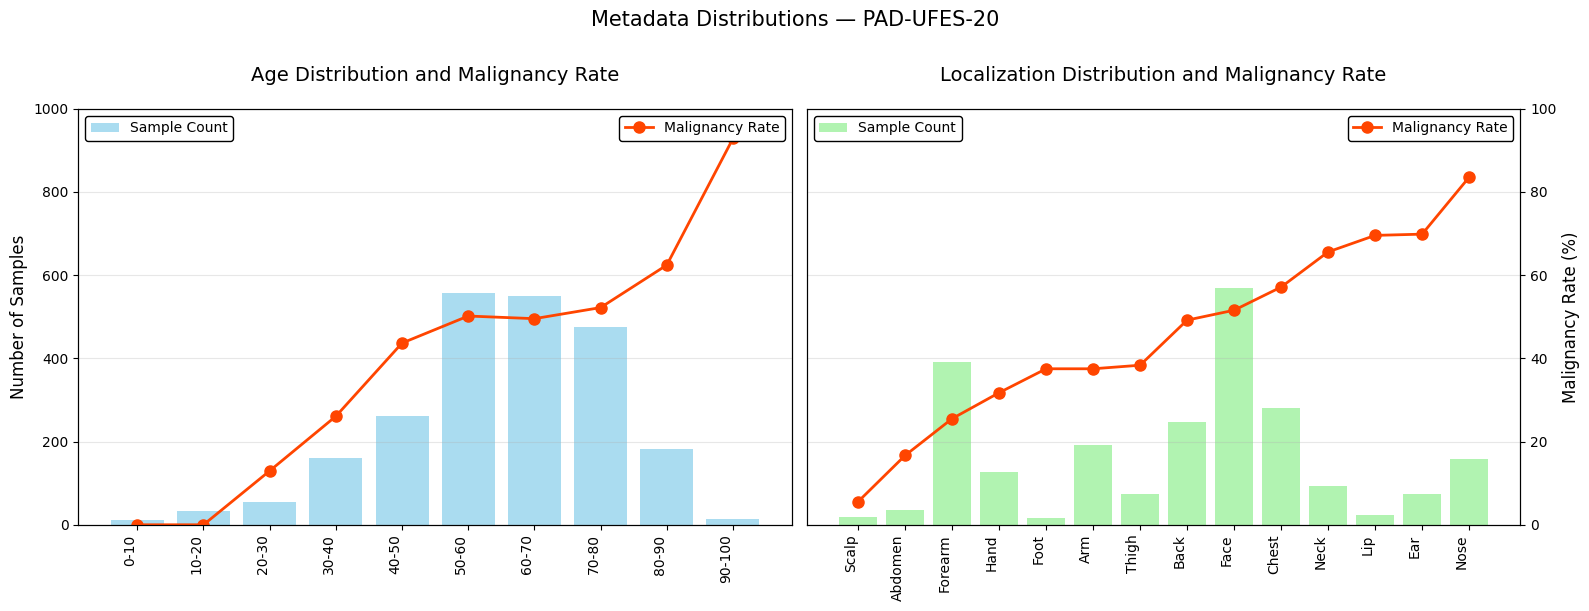

In [5]:
print("\nMetadata distributions (age, localization, malignancy rate):\n")
fig_meta = visualization.plot_metadata_distributions(meta, DANGEROUS_CLASSES, title_suffix=TITLE_SUFFIX, verbose=False)
plt.show()

In [6]:
cv_results = training.run_cv_pipeline_multi(
    pairs_data, PAIRS, X_tab, y, meta,
    class_names=CLASSES, safe_classes=SAFE_CLASSES, dangerous_classes=DANGEROUS_CLASSES,
    n_splits=5, risk_scaler=risk_scaler, routing_strategy='threshold', verbose=False,
)

I0000 00:00:1773394891.174164      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

I0000 00:00:1773394896.315322      79 service.cc:152] XLA service 0x7a24cc012cf0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773394896.315367      79 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1773394897.052526      79 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1773394900.426309      79 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


0epoch [00:00, ?epoch/s]

...

0batch [00:00, ?batch/s]

0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

In [7]:
print("\nTable 1 — Cross-Validation Results (5 folds, 3 pairs):\n")
rows_cv = []
for idx, (fold_metrics, _, _, _, _, _) in enumerate(cv_results):
    plabel = PAIR_LABELS[idx]
    for model in ['lite', 'heavy', 'dynamic']:
        mname = 'Lite' if model == 'lite' else 'Heavy' if model == 'heavy' else 'EcoFair'
        rows_cv.append({
            'Pair': plabel,
            'Model': mname,
            'Macro F1': f"{np.mean(fold_metrics[f'macro_f1_{model}']):.4f} ± {np.std(fold_metrics[f'macro_f1_{model}']):.4f}",
            'Balanced Acc': f"{np.mean(fold_metrics[f'balanced_acc_{model}']):.4f} ± {np.std(fold_metrics[f'balanced_acc_{model}']):.4f}",
            'Malignant Recall': f"{np.mean(fold_metrics[f'malignant_recall_{model}']):.4f} ± {np.std(fold_metrics[f'malignant_recall_{model}']):.4f}",
        })
df_cv = pd.DataFrame(rows_cv)
utils.save_results_csv(df_cv, OUTPUT_DIR, 'cv_results.csv')
df_cv = pd.read_csv(os.path.join(OUTPUT_DIR, 'cv_results.csv'))
utils.show_table(df_cv)


Table 1 — Cross-Validation Results (5 folds, 3 pairs):



,Pair,Model,Macro F1,Balanced Acc,Malignant Recall
0,MobileNetV2 → ResNet50,Lite,0.5986 ± 0.0170,0.6090 ± 0.0064,0.5261 ± 0.0370
1,MobileNetV2 → ResNet50,Heavy,0.6228 ± 0.0331,0.6360 ± 0.0279,0.5365 ± 0.0479
2,MobileNetV2 → ResNet50,EcoFair,0.6157 ± 0.0253,0.6243 ± 0.0286,0.5384 ± 0.0643
3,MobileNetV3Small → DenseNet201,Lite,0.6128 ± 0.0177,0.6647 ± 0.0250,0.6267 ± 0.0676
4,MobileNetV3Small → DenseNet201,Heavy,0.6147 ± 0.0265,0.6315 ± 0.0144,0.5447 ± 0.0425
5,MobileNetV3Small → DenseNet201,EcoFair,0.6351 ± 0.0231,0.6722 ± 0.0274,0.6283 ± 0.0452
6,MobileNetV3Small → EfficientNetB6,Lite,0.6147 ± 0.0415,0.6549 ± 0.0402,0.6280 ± 0.0638
7,MobileNetV3Small → EfficientNetB6,Heavy,0.6016 ± 0.0285,0.6292 ± 0.0202,0.5561 ± 0.0261
8,MobileNetV3Small → EfficientNetB6,EcoFair,0.6374 ± 0.0357,0.6756 ± 0.0310,0.6450 ± 0.0435


In [8]:
print("\nTable 2 — Energy metrics (mean ± std over folds, 3 pairs):\n")
rows_energy = []
for idx, (fold_metrics, _, _, _, _, _) in enumerate(cv_results):
    plabel = PAIR_LABELS[idx]
    lite_dir, heavy_dir = PAIRS[idx]
    j_lite = utils.load_energy_stats(lite_dir) or 1.0
    j_heavy = utils.load_energy_stats(heavy_dir) or 2.5
    eco_mean, eco_std = np.mean(fold_metrics['energy_cost']), np.std(fold_metrics['energy_cost'])
    route_mean, route_std = np.mean(fold_metrics['routing_rate']) * 100, np.std(fold_metrics['routing_rate']) * 100
    savings = [(1 - e / j_heavy) * 100 for e in fold_metrics['energy_cost']]
    sav_mean, sav_std = np.mean(savings), np.std(savings)
    rows_energy.append({
        'Pair': plabel,
        'Lite (J)': f"{j_lite:.2f}",
        'Heavy (J)': f"{j_heavy:.2f}",
        'EcoFair (J)': f"{eco_mean:.2f} ± {eco_std:.2f}",
        'Routing (%)': f"{route_mean:.2f} ± {route_std:.2f}",
        'Savings (%)': f"{sav_mean:.2f} ± {sav_std:.2f}",
    })
df_energy = pd.DataFrame(rows_energy)
utils.save_results_csv(df_energy, OUTPUT_DIR, 'energy_metrics.csv')
df_energy = pd.read_csv(os.path.join(OUTPUT_DIR, 'energy_metrics.csv'))
utils.show_table(df_energy)


Table 2 — Energy metrics (mean ± std over folds, 3 pairs):



,Pair,Lite (J),Heavy (J),EcoFair (J),Routing (%),Savings (%)
0,MobileNetV2 → ResNet50,0.20,0.37,0.40 ± 0.01,54.28 ± 2.66,-7.73 ± 2.66
1,MobileNetV3Small → DenseNet201,0.18,0.84,0.64 ± 0.03,55.24 ± 3.31,23.86 ± 3.31
2,MobileNetV3Small → EfficientNetB6,0.18,8.49,4.93 ± 0.25,56.04 ± 2.96,41.90 ± 2.96



Confusion-matrix comparison (Lite vs Heavy vs EcoFair, 3 pairs):



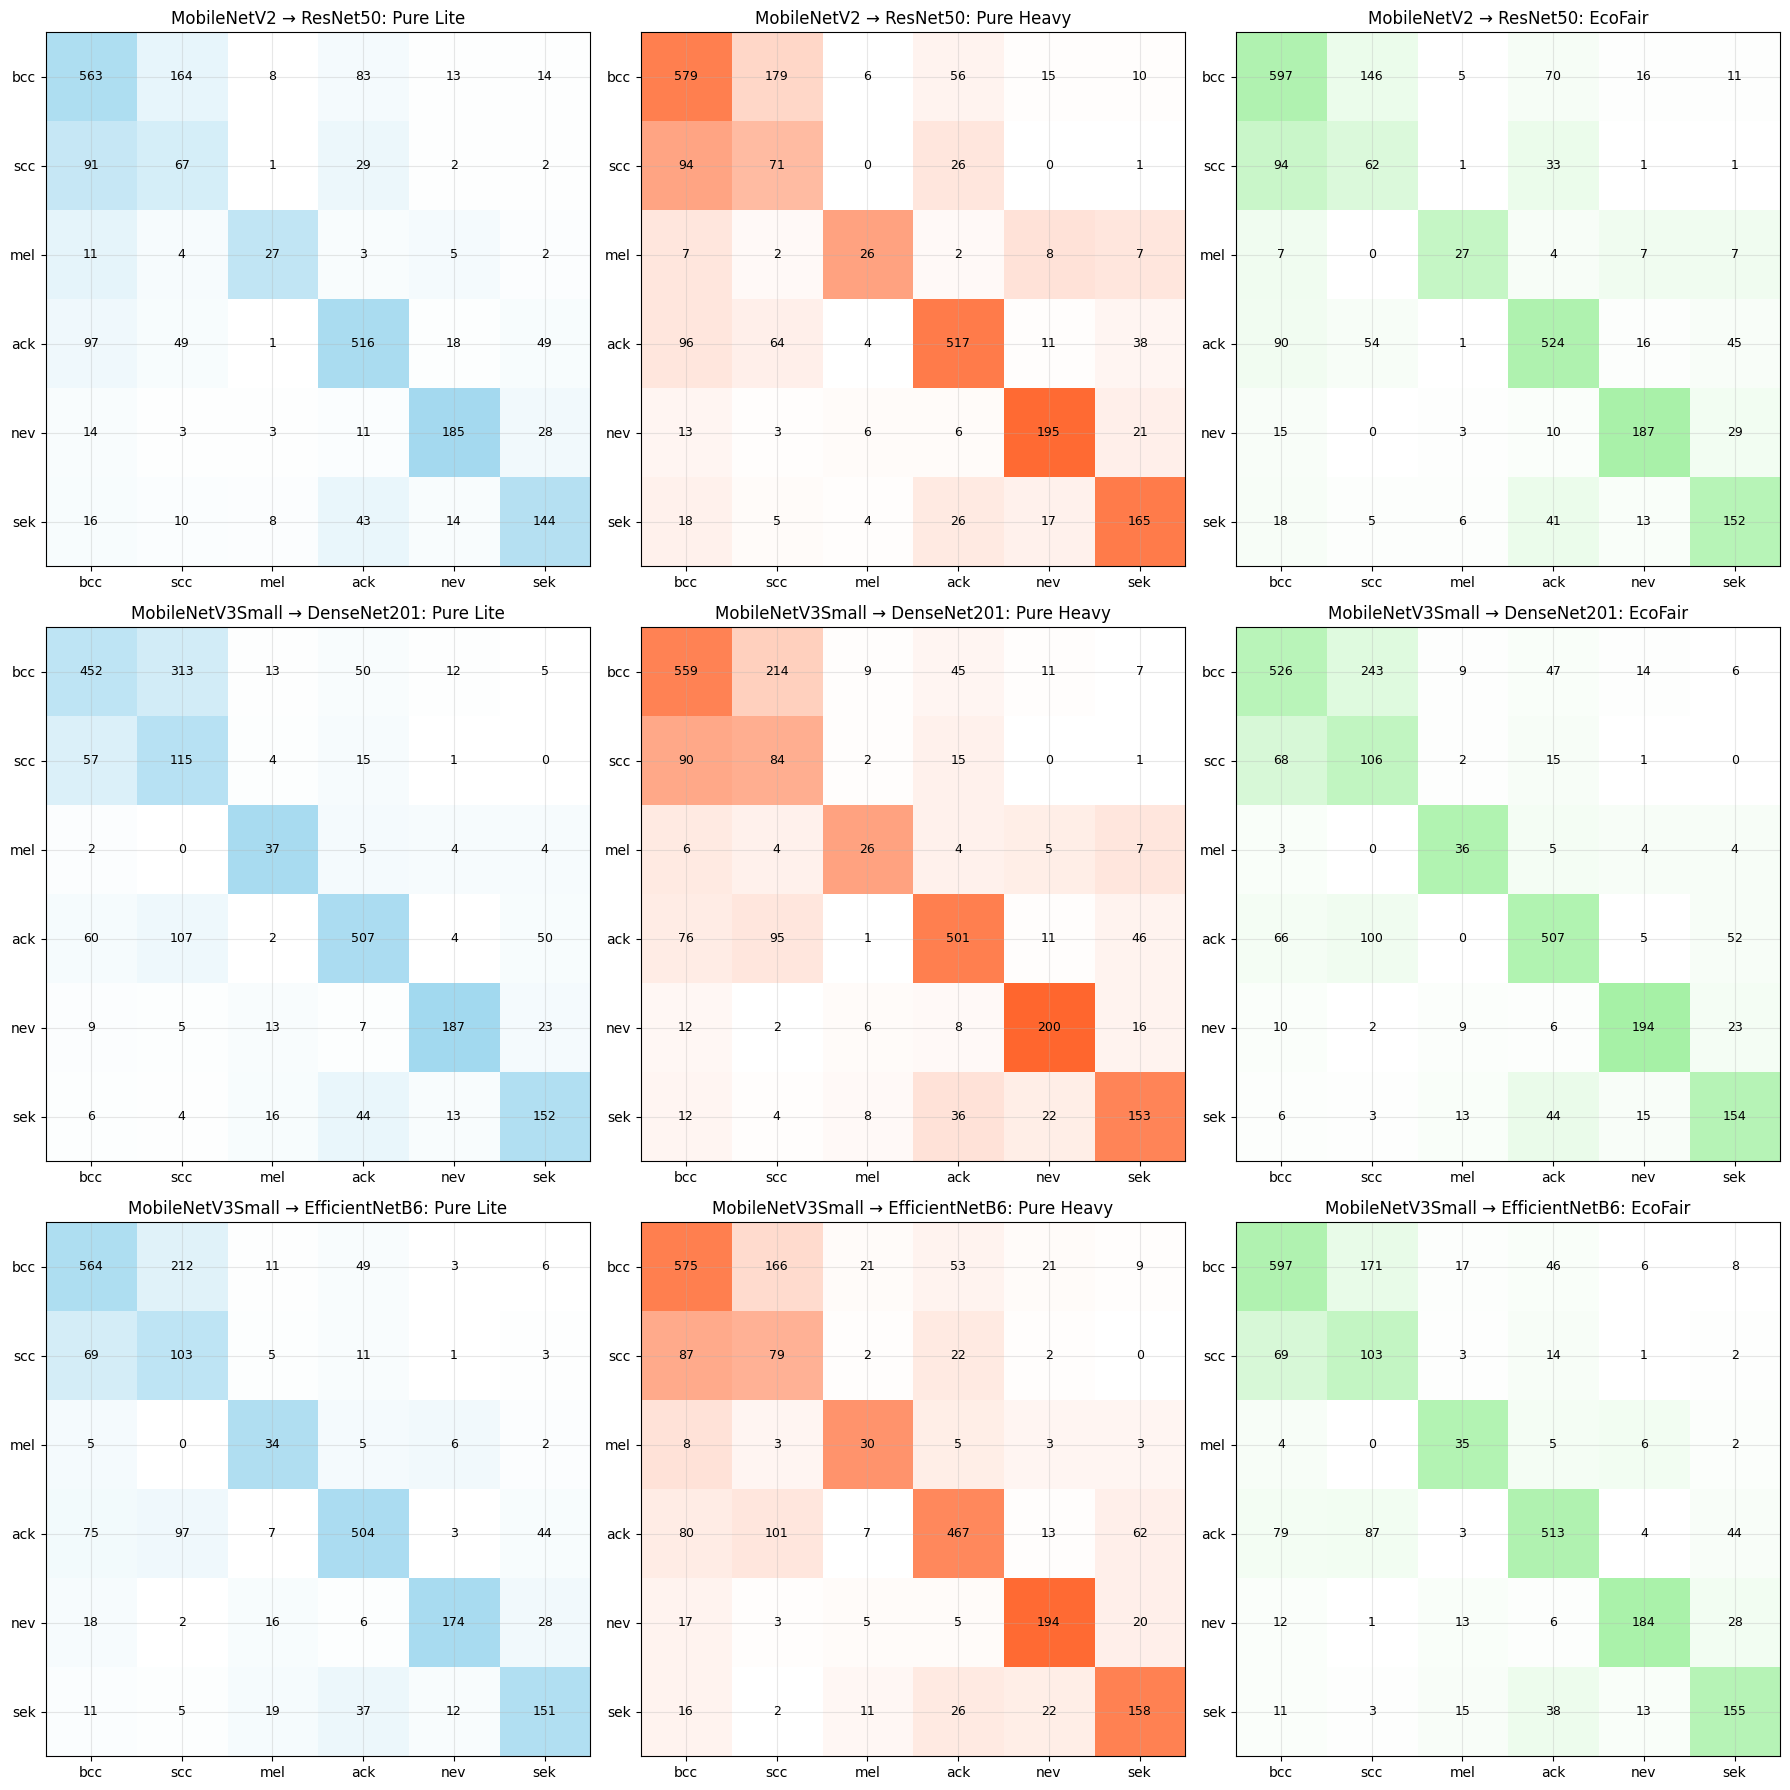

In [9]:
y_true_oof = np.argmax(y, axis=1)
pairs_results = []
for fold_metrics, oof_lite, oof_heavy, oof_dynamic, _, _ in cv_results:
    pairs_results.append((y_true_oof, oof_lite, oof_heavy, oof_dynamic))

print("\nConfusion-matrix comparison (Lite vs Heavy vs EcoFair, 3 pairs):\n")
fig_cm = visualization.plot_confusion_matrix_comparison_multi(
    pairs_results, CLASSES, pair_labels=PAIR_LABELS
)
plt.show()


Fairness summary (dangerous classes, subgroup macro TPR):



,Pair,Model,macro_tpr_mean,macro_tpr_worst_group,macro_tpr_gap
0,MobileNetV2 → ResNet50,Lite,0.4660,0.3000,0.2274
1,MobileNetV2 → ResNet50,Heavy,0.4694,0.3000,0.2426
2,MobileNetV2 → ResNet50,EcoFair,0.4678,0.3000,0.2513
3,MobileNetV3Small → DenseNet201,Lite,0.5499,0.3000,0.3421
4,MobileNetV3Small → DenseNet201,Heavy,0.5015,0.4000,0.1706
5,MobileNetV3Small → DenseNet201,EcoFair,0.5369,0.2000,0.4452
6,MobileNetV3Small → EfficientNetB6,Lite,0.5713,0.4000,0.2483
7,MobileNetV3Small → EfficientNetB6,Heavy,0.4840,0.2000,0.3826
8,MobileNetV3Small → EfficientNetB6,EcoFair,0.5865,0.4000,0.2708



Fairness grouped-bar plots (macro TPR, worst-group TPR, TPR gap):



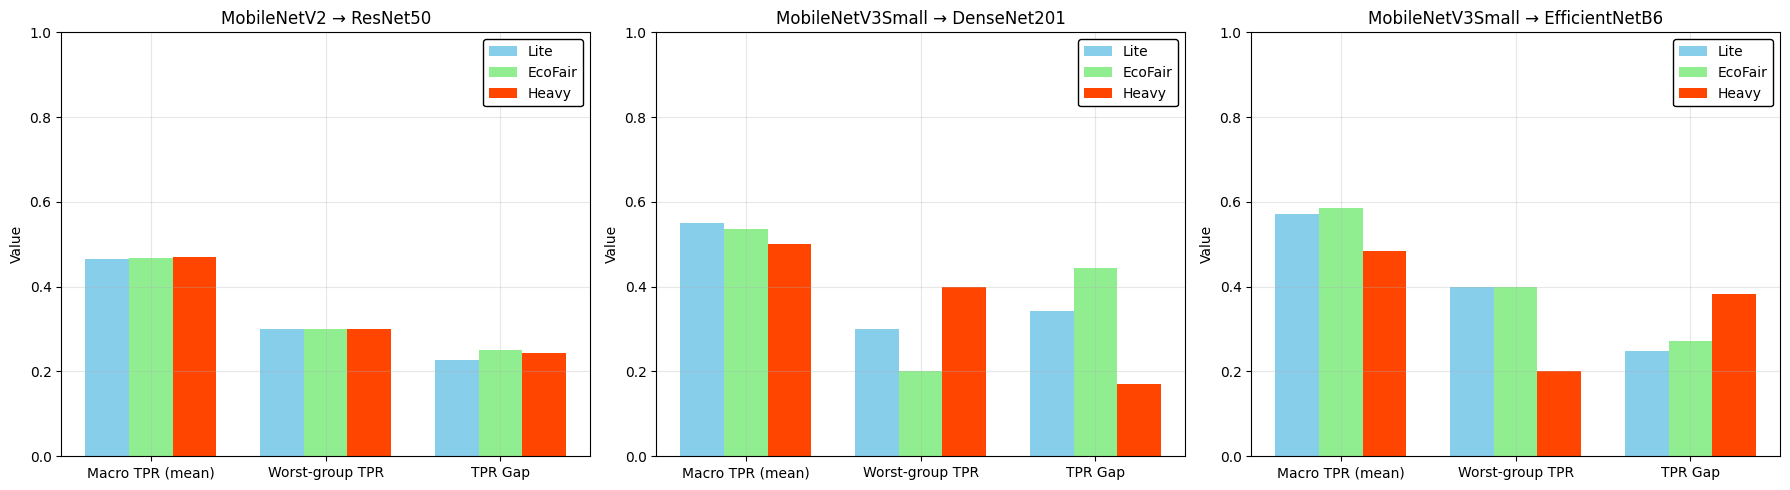

In [10]:
pairs_fairness_reports = []
for idx, (_, oof_lite, oof_heavy, oof_dynamic, _, _) in enumerate(cv_results):
    lite_pred = np.argmax(oof_lite, axis=1)
    heavy_pred = np.argmax(oof_heavy, axis=1)
    dynamic_pred = np.argmax(oof_dynamic, axis=1)
    fl = fairness.generate_fairness_report(y_true_oof, lite_pred, meta, CLASSES)
    fh = fairness.generate_fairness_report(y_true_oof, heavy_pred, meta, CLASSES)
    fe = fairness.generate_fairness_report(y_true_oof, dynamic_pred, meta, CLASSES)
    pairs_fairness_reports.append({'Lite': fl, 'Heavy': fh, 'EcoFair': fe})

def _fairness_summary(reports, dangerous_classes):
    rows = []
    for label, df in reports.items():
        if df is None or df.empty:
            rows.append({'Model': label, 'macro_tpr_mean': np.nan, 'macro_tpr_worst_group': np.nan, 'macro_tpr_gap': np.nan})
            continue
        subset = df[df['Class'].isin(dangerous_classes)].copy()
        subset['_tpr'] = pd.to_numeric(subset['Equal_Opportunity_TPR'], errors='coerce')
        sg_macro = subset.groupby('Subgroup')['_tpr'].mean().dropna()
        if sg_macro.empty:
            rows.append({'Model': label, 'macro_tpr_mean': np.nan, 'macro_tpr_worst_group': np.nan, 'macro_tpr_gap': np.nan})
            continue
        rows.append({
            'Model': label,
            'macro_tpr_mean': round(float(sg_macro.mean()), 4),
            'macro_tpr_worst_group': round(float(sg_macro.min()), 4),
            'macro_tpr_gap': round(float(sg_macro.max() - sg_macro.min()), 4),
        })
    return pd.DataFrame(rows).set_index('Model')

pd.set_option('display.float_format', '{:.4f}'.format)
rows_fairness = []
for idx, reports in enumerate(pairs_fairness_reports):
    sf = _fairness_summary(reports, DANGEROUS_CLASSES).reset_index()
    sf.insert(0, 'Pair', PAIR_LABELS[idx])
    rows_fairness.append(sf)
df_fairness = pd.concat(rows_fairness, ignore_index=True)
utils.save_results_csv(df_fairness, OUTPUT_DIR, 'fairness_summary.csv')
df_fairness = pd.read_csv(os.path.join(OUTPUT_DIR, 'fairness_summary.csv'))
print("\nFairness summary (dangerous classes, subgroup macro TPR):\n")
utils.show_table(df_fairness)

print("\nFairness grouped-bar plots (macro TPR, worst-group TPR, TPR gap):\n")
fig_fairness = visualization.plot_fairness_summary_grouped(
    pairs_fairness_reports, DANGEROUS_CLASSES, pair_labels=PAIR_LABELS
)
plt.show()

In [11]:
def _subgroup_to_df(fairness_df, metric_col):
    if fairness_df is None or fairness_df.empty:
        return pd.DataFrame()
    df = fairness_df.copy()
    df['Subgroup'] = df.apply(lambda r: f"{r['Subgroup']} (n={int(r['Count'])})", axis=1)
    piv = df.pivot(index='Subgroup', columns='Class', values=metric_col).reset_index()
    return piv

subgroup_acc_list, subgroup_eo_list, subgroup_dp_list = [], [], []
for idx, reports in enumerate(pairs_fairness_reports):
    plabel = PAIR_LABELS[idx]
    for model_name, rep in [('Lite', reports['Lite']), ('Heavy', reports['Heavy']), ('EcoFair', reports['EcoFair'])]:
        for piv, lst in [
            (_subgroup_to_df(rep, 'Accuracy'), subgroup_acc_list),
            (_subgroup_to_df(rep, 'Equal_Opportunity_TPR'), subgroup_eo_list),
            (_subgroup_to_df(rep, 'Demographic_Parity_Rate'), subgroup_dp_list),
        ]:
            if piv.empty:
                continue
            piv = piv.copy()
            piv.insert(0, 'Pair', plabel)
            piv.insert(1, 'Model', model_name)
            lst.append(piv)

for fname, lst, title in [
    ('subgroup_accuracy.csv', subgroup_acc_list, 'Subgroup Accuracy (per Pair, per Model)'),
    ('subgroup_eo.csv', subgroup_eo_list, 'Subgroup Equal Opportunity TPR (per Pair, per Model)'),
    ('subgroup_dp.csv', subgroup_dp_list, 'Subgroup Demographic Parity Rate (per Pair, per Model)'),
]:
    if lst:
        df_sg = pd.concat(lst, ignore_index=True)
        utils.save_results_csv(df_sg, OUTPUT_DIR, fname)
        df_sg = pd.read_csv(os.path.join(OUTPUT_DIR, fname))
        print(f"\n{title}:\n")
        utils.show_table(df_sg)


Subgroup Accuracy (per Pair, per Model):



,Pair,Model,Subgroup,ack,bcc,mel,nev,scc,sek
0,MobileNetV2 → ResNet50,Lite,Age 30-60 (n=978),0.8384,0.8037,0.9826,0.9100,0.9080,0.9090
1,MobileNetV2 → ResNet50,Lite,Age 60+ (n=1221),0.8174,0.7404,0.9779,0.9869,0.7830,0.9214
2,MobileNetV2 → ResNet50,Lite,Age <30 (n=99),0.9798,0.9798,0.9798,0.9293,1.0000,0.9899
3,MobileNetV2 → ResNet50,Lite,Sex: Female (n=753),0.7915,0.6799,0.9721,0.9495,0.7875,0.9456
4,MobileNetV2 → ResNet50,Lite,Sex: Male (n=741),0.8300,0.6397,0.9676,0.9744,0.7382,0.9649
5,MobileNetV2 → ResNet50,Heavy,Age 30-60 (n=978),0.8599,0.8149,0.9755,0.9243,0.9070,0.9315
6,MobileNetV2 → ResNet50,Heavy,Age 60+ (n=1221),0.8436,0.7453,0.9836,0.9836,0.7682,0.9353
7,MobileNetV2 → ResNet50,Heavy,Age <30 (n=99),0.9899,0.9798,0.9798,0.9394,1.0000,0.9899
8,MobileNetV2 → ResNet50,Heavy,Sex: Female (n=753),0.8154,0.6946,0.9655,0.9509,0.7742,0.9522
9,MobileNetV2 → ResNet50,Heavy,Sex: Male (n=741),0.8489,0.6464,0.9730,0.9717,0.7247,0.9744



Subgroup Equal Opportunity TPR (per Pair, per Model):



,Pair,Model,Subgroup,ack,bcc,mel,nev,scc,sek
0,MobileNetV2 → ResNet50,Lite,Age 30-60 (n=978),0.7425,0.7119,0.6296,0.6857,0.2340,0.4638
1,MobileNetV2 → ResNet50,Lite,Age 60+ (n=1221),0.6785,0.6326,0.4348,0.0000,0.3862,0.6788
2,MobileNetV2 → ResNet50,Lite,Age <30 (n=99),0.0000,0.6000,0.0000,0.9889,NaN,0.0000
3,MobileNetV2 → ResNet50,Lite,Sex: Female (n=753),0.4641,0.6552,0.5714,0.6939,0.3556,0.1852
4,MobileNetV2 → ResNet50,Lite,Sex: Male (n=741),0.3769,0.6765,0.4583,0.5769,0.3431,0.3000
5,MobileNetV2 → ResNet50,Heavy,Age 30-60 (n=978),0.7485,0.7645,0.5556,0.7500,0.1702,0.5362
6,MobileNetV2 → ResNet50,Heavy,Age 60+ (n=1221),0.6759,0.6263,0.4783,0.0000,0.4345,0.7758
7,MobileNetV2 → ResNet50,Heavy,Age <30 (n=99),0.0000,0.6000,0.0000,1.0000,NaN,0.0000
8,MobileNetV2 → ResNet50,Heavy,Sex: Female (n=753),0.4444,0.6970,0.4643,0.6939,0.3222,0.2593
9,MobileNetV2 → ResNet50,Heavy,Sex: Male (n=741),0.3692,0.6743,0.5417,0.5769,0.4118,0.4000



Subgroup Demographic Parity Rate (per Pair, per Model):



,Pair,Model,Subgroup,ack,bcc,mel,nev,scc,sek
0,MobileNetV2 → ResNet50,Lite,Age 30-60 (n=978),0.3272,0.3528,0.0245,0.1431,0.0665,0.0859
1,MobileNetV2 → ResNet50,Lite,Age 60+ (n=1221),0.2981,0.3636,0.0197,0.0016,0.1900,0.1269
2,MobileNetV2 → ResNet50,Lite,Age <30 (n=99),0.0101,0.0303,0.0000,0.9596,0.0000,0.0000
3,MobileNetV2 → ResNet50,Lite,Sex: Female (n=753),0.1939,0.4874,0.0332,0.0757,0.1780,0.0319
4,MobileNetV2 → ResNet50,Lite,Sex: Male (n=741),0.1269,0.5695,0.0297,0.0310,0.2186,0.0243
5,MobileNetV2 → ResNet50,Heavy,Age 30-60 (n=978),0.3098,0.3804,0.0276,0.1472,0.0613,0.0736
6,MobileNetV2 → ResNet50,Heavy,Age 60+ (n=1221),0.2703,0.3538,0.0156,0.0049,0.2162,0.1392
7,MobileNetV2 → ResNet50,Heavy,Age <30 (n=99),0.0000,0.0303,0.0000,0.9697,0.0000,0.0000
8,MobileNetV2 → ResNet50,Heavy,Sex: Female (n=753),0.1620,0.5179,0.0319,0.0744,0.1833,0.0305
9,MobileNetV2 → ResNet50,Heavy,Sex: Male (n=741),0.1053,0.5601,0.0297,0.0337,0.2510,0.0202



Clinical safety rescue plots (subgroup malignancy TPR, Lite vs EcoFair vs Heavy):



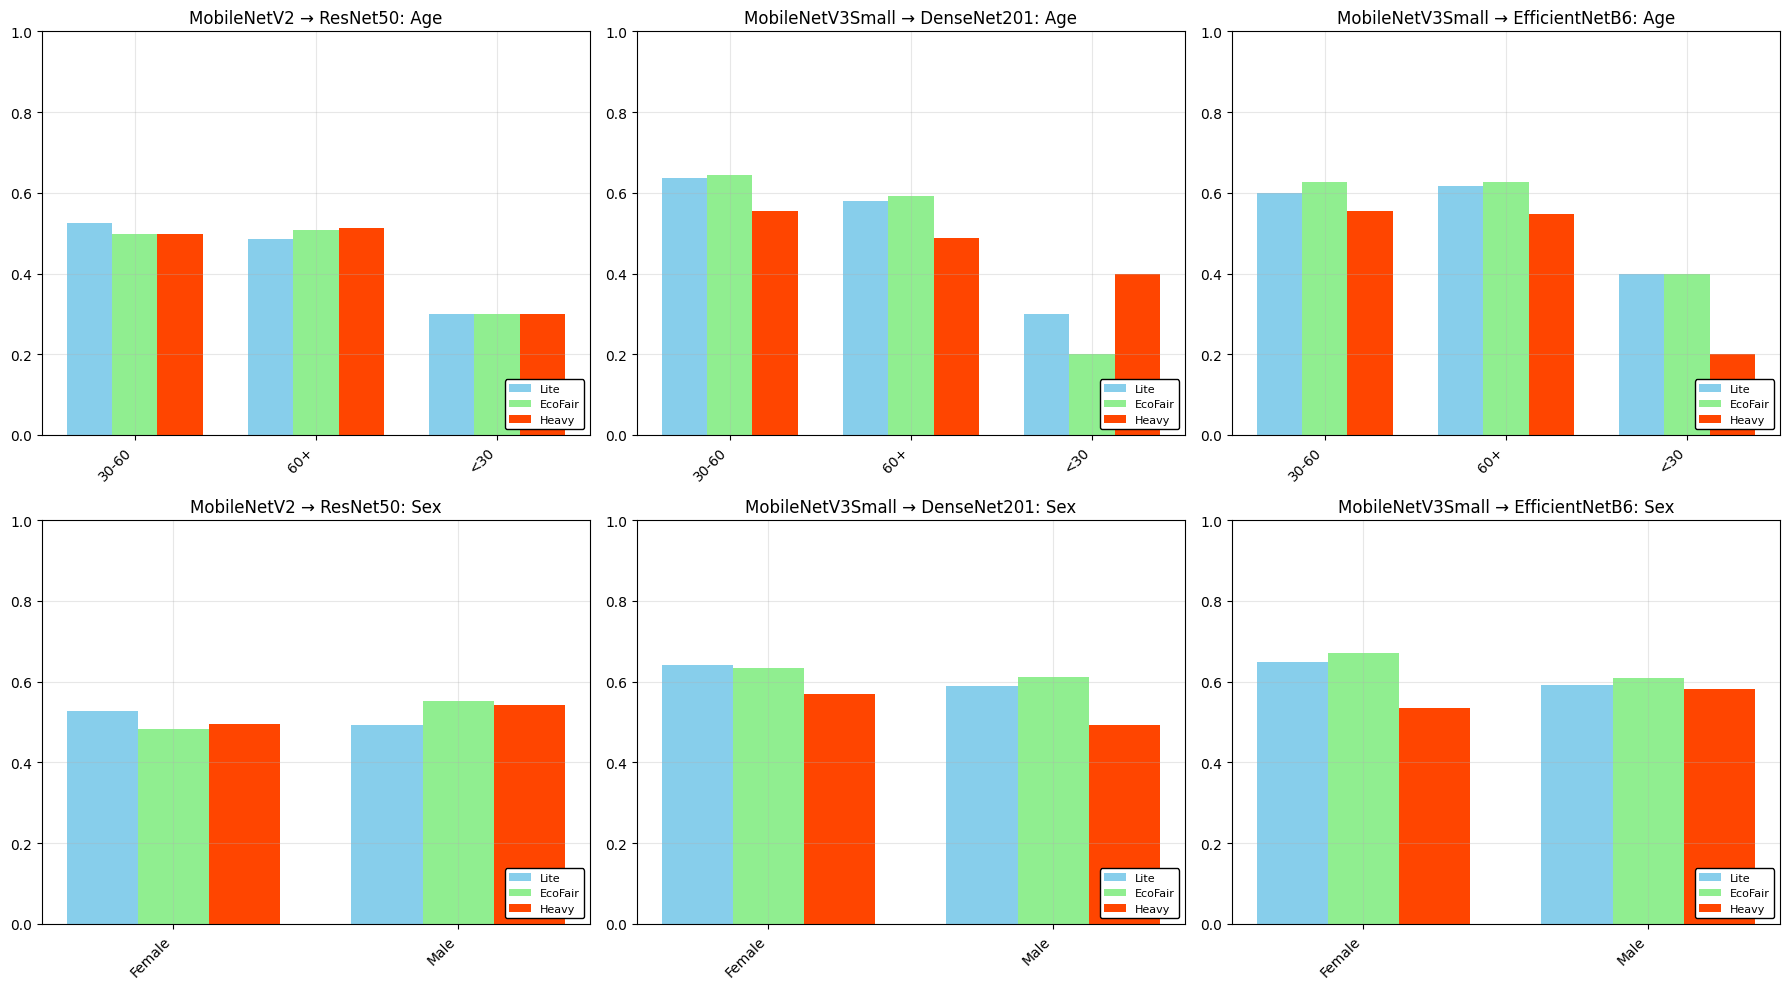

In [12]:
pairs_fairness_tuples = [(r['Lite'], r['Heavy'], r['EcoFair']) for r in pairs_fairness_reports]
print("\nClinical safety rescue plots (subgroup malignancy TPR, Lite vs EcoFair vs Heavy):\n")
fig_clinical = visualization.plot_clinical_safety_rescue_multi(
    pairs_fairness_tuples, DANGEROUS_CLASSES, pair_labels=PAIR_LABELS
)
plt.show()


Pareto frontier: Total energy vs worst-group TPR (3 pairs):



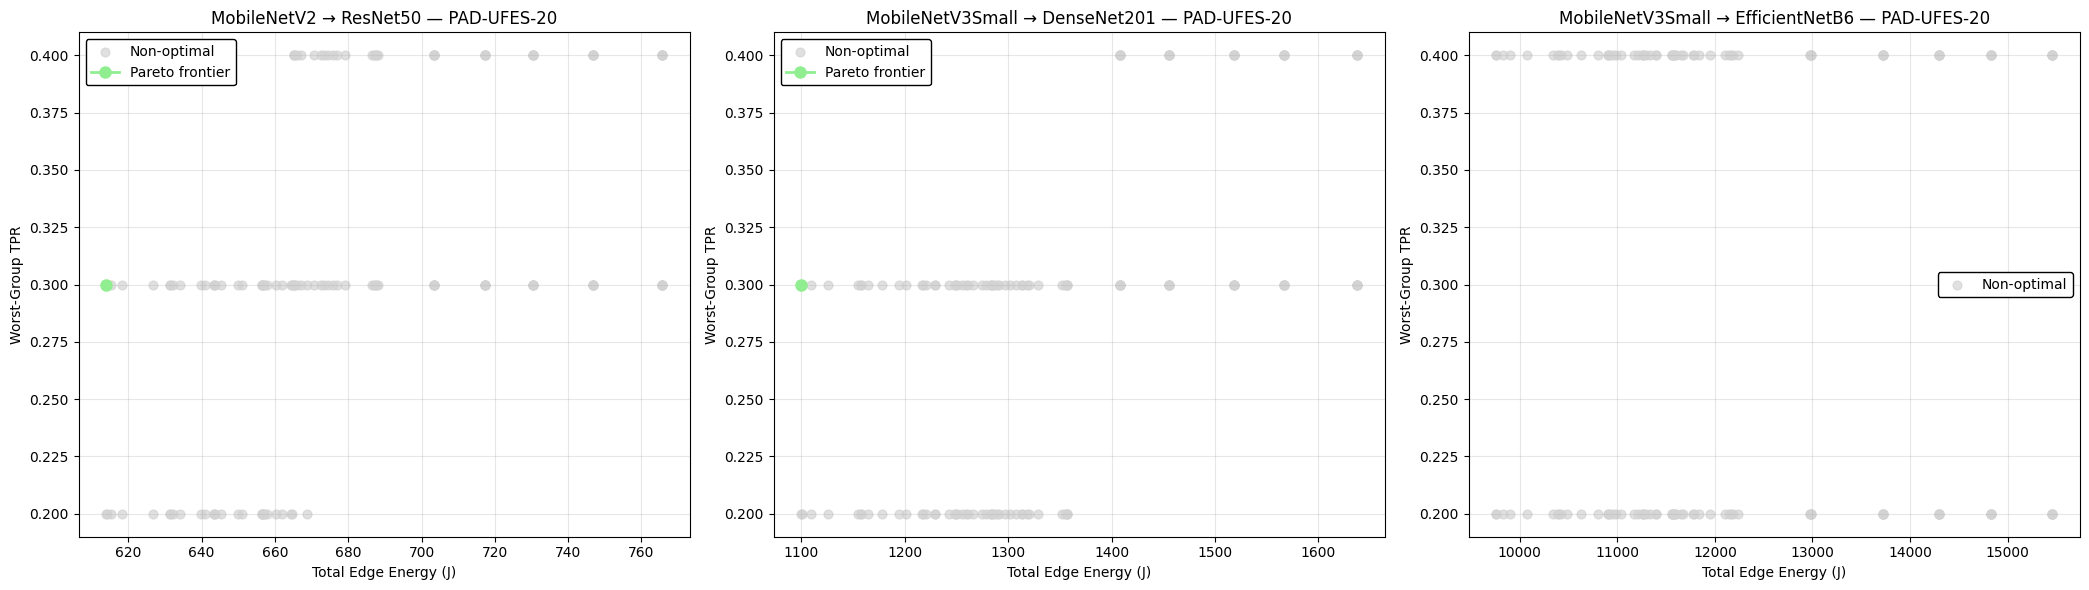

In [13]:
pairs_oof = [(r[1], r[2]) for r in cv_results]  # oof_lite, oof_heavy per pair
pairs_joules = [(utils.load_energy_stats(PAIRS[i][0]) or 1.0, utils.load_energy_stats(PAIRS[i][1]) or 2.5) for i in range(len(PAIRS))]
print("\nPareto frontier: Total energy vs worst-group TPR (3 pairs):\n")
fig_pareto = visualization.plot_pareto_frontier_multi(
    pairs_oof, pairs_joules, y_true_oof, meta, CLASSES, SAFE_CLASSES, DANGEROUS_CLASSES,
    pair_labels=PAIR_LABELS, title_suffix=TITLE_SUFFIX,
    csv_path=os.path.join(OUTPUT_DIR, 'pareto_points.csv')
)
plt.show()